# Flood Prediction System

## Project Objective

The objective of this project is to develop a Machine Learning based Flood Prediction System capable of predicting flood occurrence using environmental and rainfall-related parameters. The project follows the complete Machine Learning lifecycle, including data loading, exploratory data analysis, preprocessing, model building, model evaluation, and deployment using Flask.

---

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import joblib

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

print("=" * 60)
print("Libraries Imported Successfully")
print("=" * 60)

Libraries Imported Successfully


In [ ]:
PROJECT_ROOT = Path.cwd().parents[1]

DATASET_PATH = PROJECT_ROOT / "dataset" / "flood_dataset.xlsx"

MODEL_DIR = PROJECT_ROOT / "backend" / "models"

ASSET_DIR = PROJECT_ROOT / "assets"

MODEL_DIR.mkdir(parents=True, exist_ok=True)
ASSET_DIR.mkdir(parents=True, exist_ok=True)

print("Project Root :", PROJECT_ROOT)
print("Dataset Path :", DATASET_PATH)

Project Root : c:\projects\Raising Water(APSCHE)
Dataset Path : c:\projects\Raising Water(APSCHE)\dataset\flood_dataset.xlsx


In [ ]:
df = pd.read_excel(DATASET_PATH)

print("Dataset Loaded Successfully")

df.head()
print("Rows    :", df.shape[0])
print("Columns :", df.shape[1])

Dataset Loaded Successfully
Rows    : 115
Columns : 11


In [6]:
df.columns.tolist()

['Temp',
 'Humidity',
 'Cloud Cover',
 'ANNUAL',
 'Jan-Feb',
 'Mar-May',
 'Jun-Sep',
 'Oct-Dec',
 'avgjune',
 'sub',
 'flood']

In [ ]:
df.info()
df.dtypes
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 115 entries, 0 to 114
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Temp         115 non-null    int64  
 1   Humidity     115 non-null    int64  
 2   Cloud Cover  115 non-null    int64  
 3   ANNUAL       115 non-null    float64
 4   Jan-Feb      115 non-null    float64
 5   Mar-May      115 non-null    float64
 6   Jun-Sep      115 non-null    float64
 7   Oct-Dec      115 non-null    float64
 8   avgjune      115 non-null    float64
 9   sub          115 non-null    float64
 10  flood        115 non-null    int64  
dtypes: float64(7), int64(4)
memory usage: 10.0 KB


Temp           0
Humidity       0
Cloud Cover    0
ANNUAL         0
Jan-Feb        0
Mar-May        0
Jun-Sep        0
Oct-Dec        0
avgjune        0
sub            0
flood          0
dtype: int64

In [ ]:
df.columns.tolist()
df.info()
df.dtypes
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 115 entries, 0 to 114
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Temp         115 non-null    int64  
 1   Humidity     115 non-null    int64  
 2   Cloud Cover  115 non-null    int64  
 3   ANNUAL       115 non-null    float64
 4   Jan-Feb      115 non-null    float64
 5   Mar-May      115 non-null    float64
 6   Jun-Sep      115 non-null    float64
 7   Oct-Dec      115 non-null    float64
 8   avgjune      115 non-null    float64
 9   sub          115 non-null    float64
 10  flood        115 non-null    int64  
dtypes: float64(7), int64(4)
memory usage: 10.0 KB


Temp           0
Humidity       0
Cloud Cover    0
ANNUAL         0
Jan-Feb        0
Mar-May        0
Jun-Sep        0
Oct-Dec        0
avgjune        0
sub            0
flood          0
dtype: int64

In [5]:
print("Duplicate Records :", df.duplicated().sum())

Duplicate Records : 0


In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Temp,115.0,29.600000,1.122341,28.0,29.000000,30.000000,31.000000,31.000000
Humidity,115.0,73.852174,2.947623,70.0,71.000000,74.000000,76.000000,79.000000
Cloud Cover,115.0,36.286957,4.330158,30.0,32.500000,36.000000,40.000000,44.000000
ANNUAL,115.0,2925.487826,422.112193,2068.8,2627.900000,2937.500000,3164.100000,4257.800000
Jan-Feb,115.0,27.739130,22.361032,0.3,10.250000,20.500000,41.600000,98.100000
Mar-May,115.0,377.253913,151.091850,89.9,276.750000,342.000000,442.300000,915.200000
Jun-Sep,115.0,2022.840870,386.254397,1104.3,1768.850000,1948.700000,2242.900000,3451.300000
Oct-Dec,115.0,497.636522,129.860643,166.6,407.450000,501.500000,584.550000,823.300000
avgjune,115.0,218.100870,62.547597,65.6,179.666667,211.033333,263.833333,366.066667
sub,115.0,439.801739,210.438813,34.2,295.000000,430.600000,577.650000,982.700000


In [7]:
df.nunique()

Temp             4
Humidity        10
Cloud Cover     15
ANNUAL         115
Jan-Feb        103
Mar-May        111
Jun-Sep        113
Oct-Dec        115
avgjune        113
sub            114
flood            2
dtype: int64

In [8]:
TARGET = "flood"

print("Target Column :", TARGET)

Target Column : flood


In [9]:
numerical_columns = df.select_dtypes(include=np.number).columns.tolist()

print("Numerical Features")

numerical_columns

Numerical Features


['Temp',
 'Humidity',
 'Cloud Cover',
 'ANNUAL',
 'Jan-Feb',
 'Mar-May',
 'Jun-Sep',
 'Oct-Dec',
 'avgjune',
 'sub',
 'flood']

In [10]:
categorical_columns = df.select_dtypes(exclude=np.number).columns.tolist()

print("Categorical Features")

categorical_columns

Categorical Features


[]

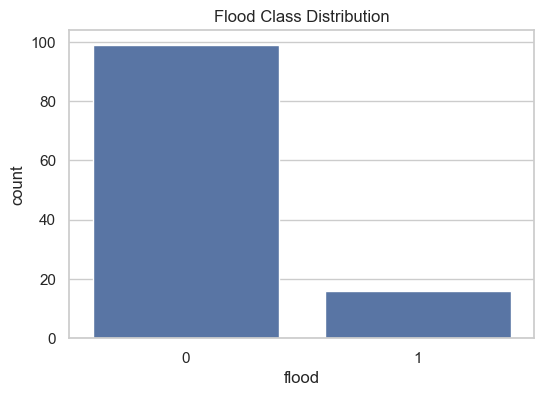

flood
0    99
1    16
Name: count, dtype: int64


In [11]:
plt.figure(figsize=(6,4))

sns.countplot(x="flood", data=df)

plt.title("Flood Class Distribution")

plt.show()

print(df["flood"].value_counts())

In [12]:
print("=" * 60)

print("Flood Prediction Dataset Summary")

print("=" * 60)

print(f"Rows                : {df.shape[0]}")
print(f"Columns             : {df.shape[1]}")
print(f"Missing Values      : {df.isnull().sum().sum()}")
print(f"Duplicate Records   : {df.duplicated().sum()}")
print(f"Target Column       : {TARGET}")
print(f"Numerical Features  : {len(numerical_columns)}")
print(f"Categorical Features: {len(categorical_columns)}")

print("=" * 60)

Flood Prediction Dataset Summary
Rows                : 115
Columns             : 11
Missing Values      : 0
Duplicate Records   : 0
Target Column       : flood
Numerical Features  : 11
Categorical Features: 0


# 2. Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is performed to understand the characteristics of the dataset before preprocessing and model training. It helps identify feature distributions, relationships, correlations, and potential anomalies.

In [13]:
feature_columns = [col for col in df.columns if col != TARGET]

print("Feature Columns:\n")
feature_columns

Feature Columns:



['Temp',
 'Humidity',
 'Cloud Cover',
 'ANNUAL',
 'Jan-Feb',
 'Mar-May',
 'Jun-Sep',
 'Oct-Dec',
 'avgjune',
 'sub']

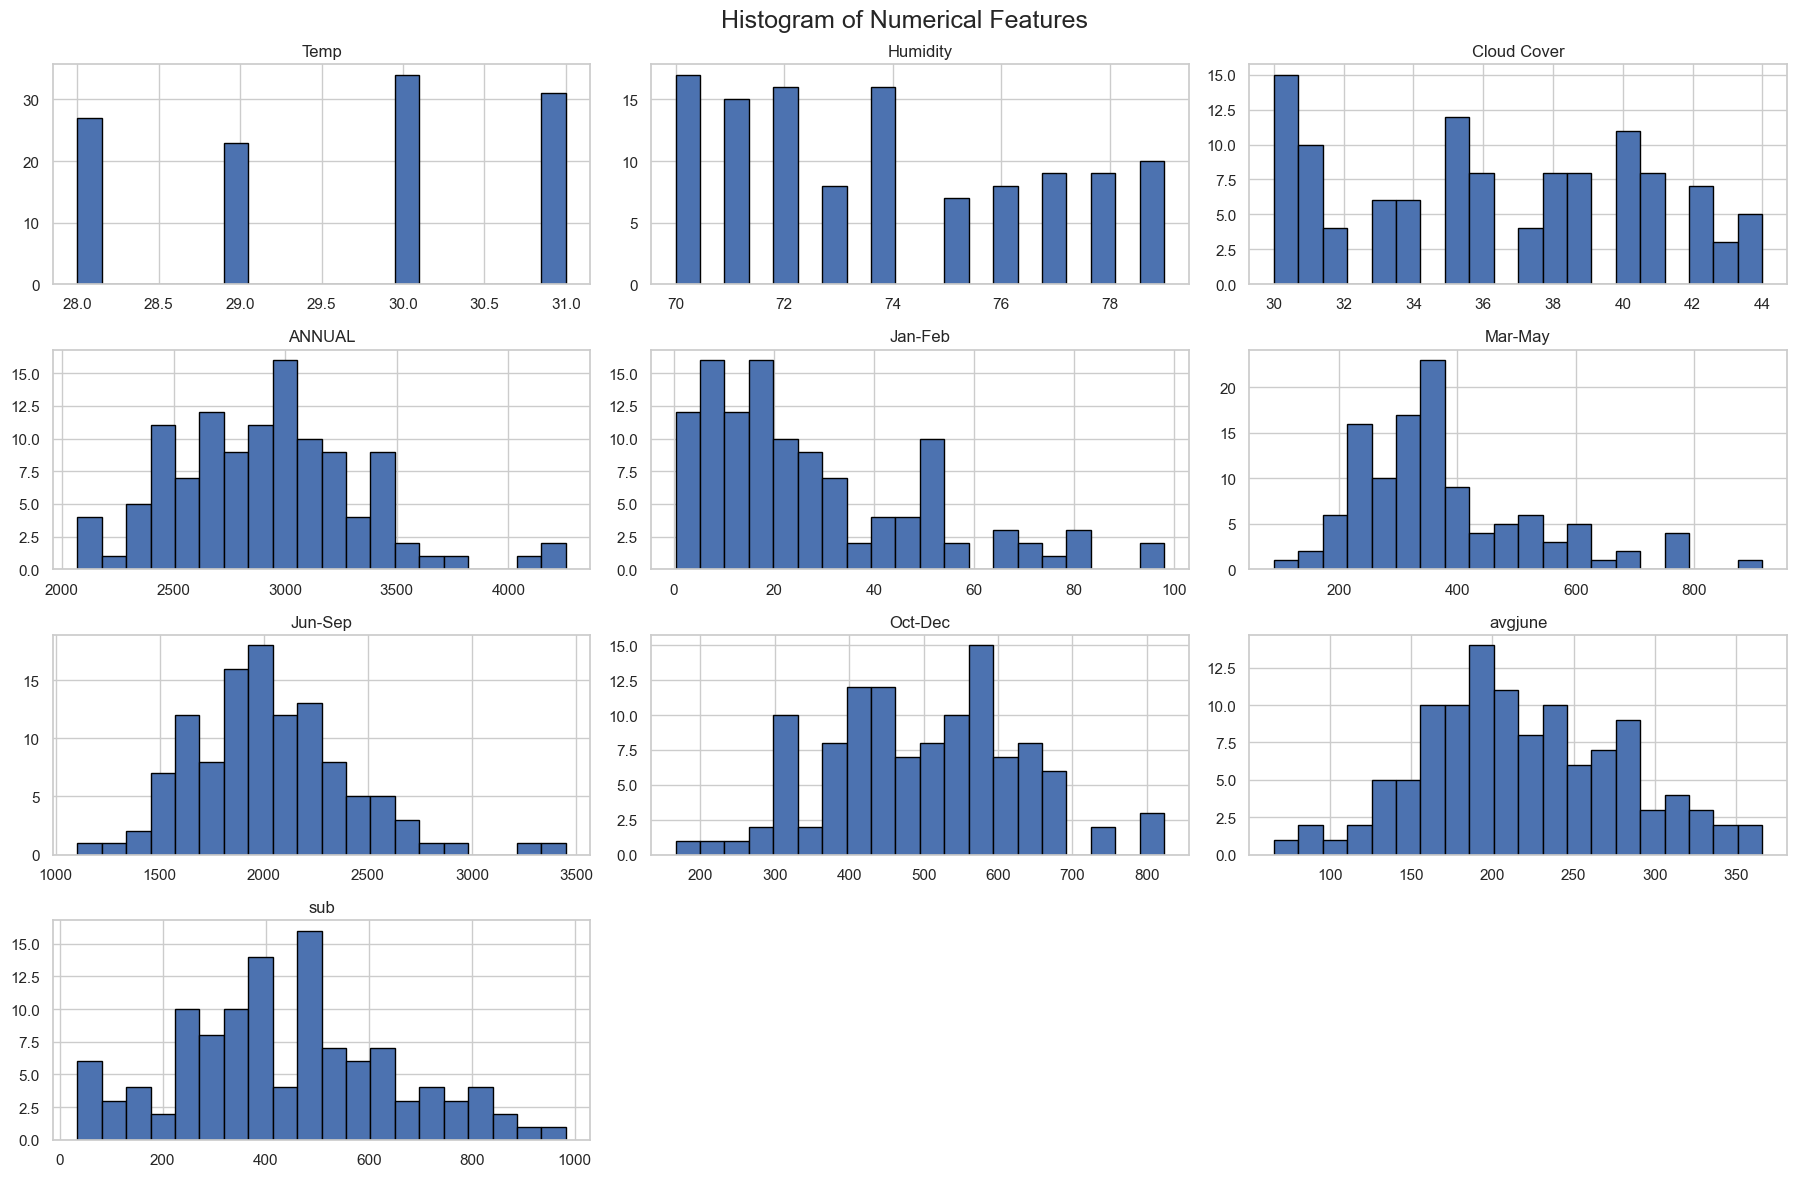

In [14]:
df[feature_columns].hist(
    figsize=(18,12),
    bins=20,
    edgecolor="black"
)

plt.suptitle("Histogram of Numerical Features", fontsize=18)

plt.tight_layout()

plt.show()

### Observation

The histograms show the distribution of every numerical feature.

Some rainfall-related features are slightly skewed, while others appear normally distributed. This helps in understanding whether feature scaling or transformations may be required before model training.

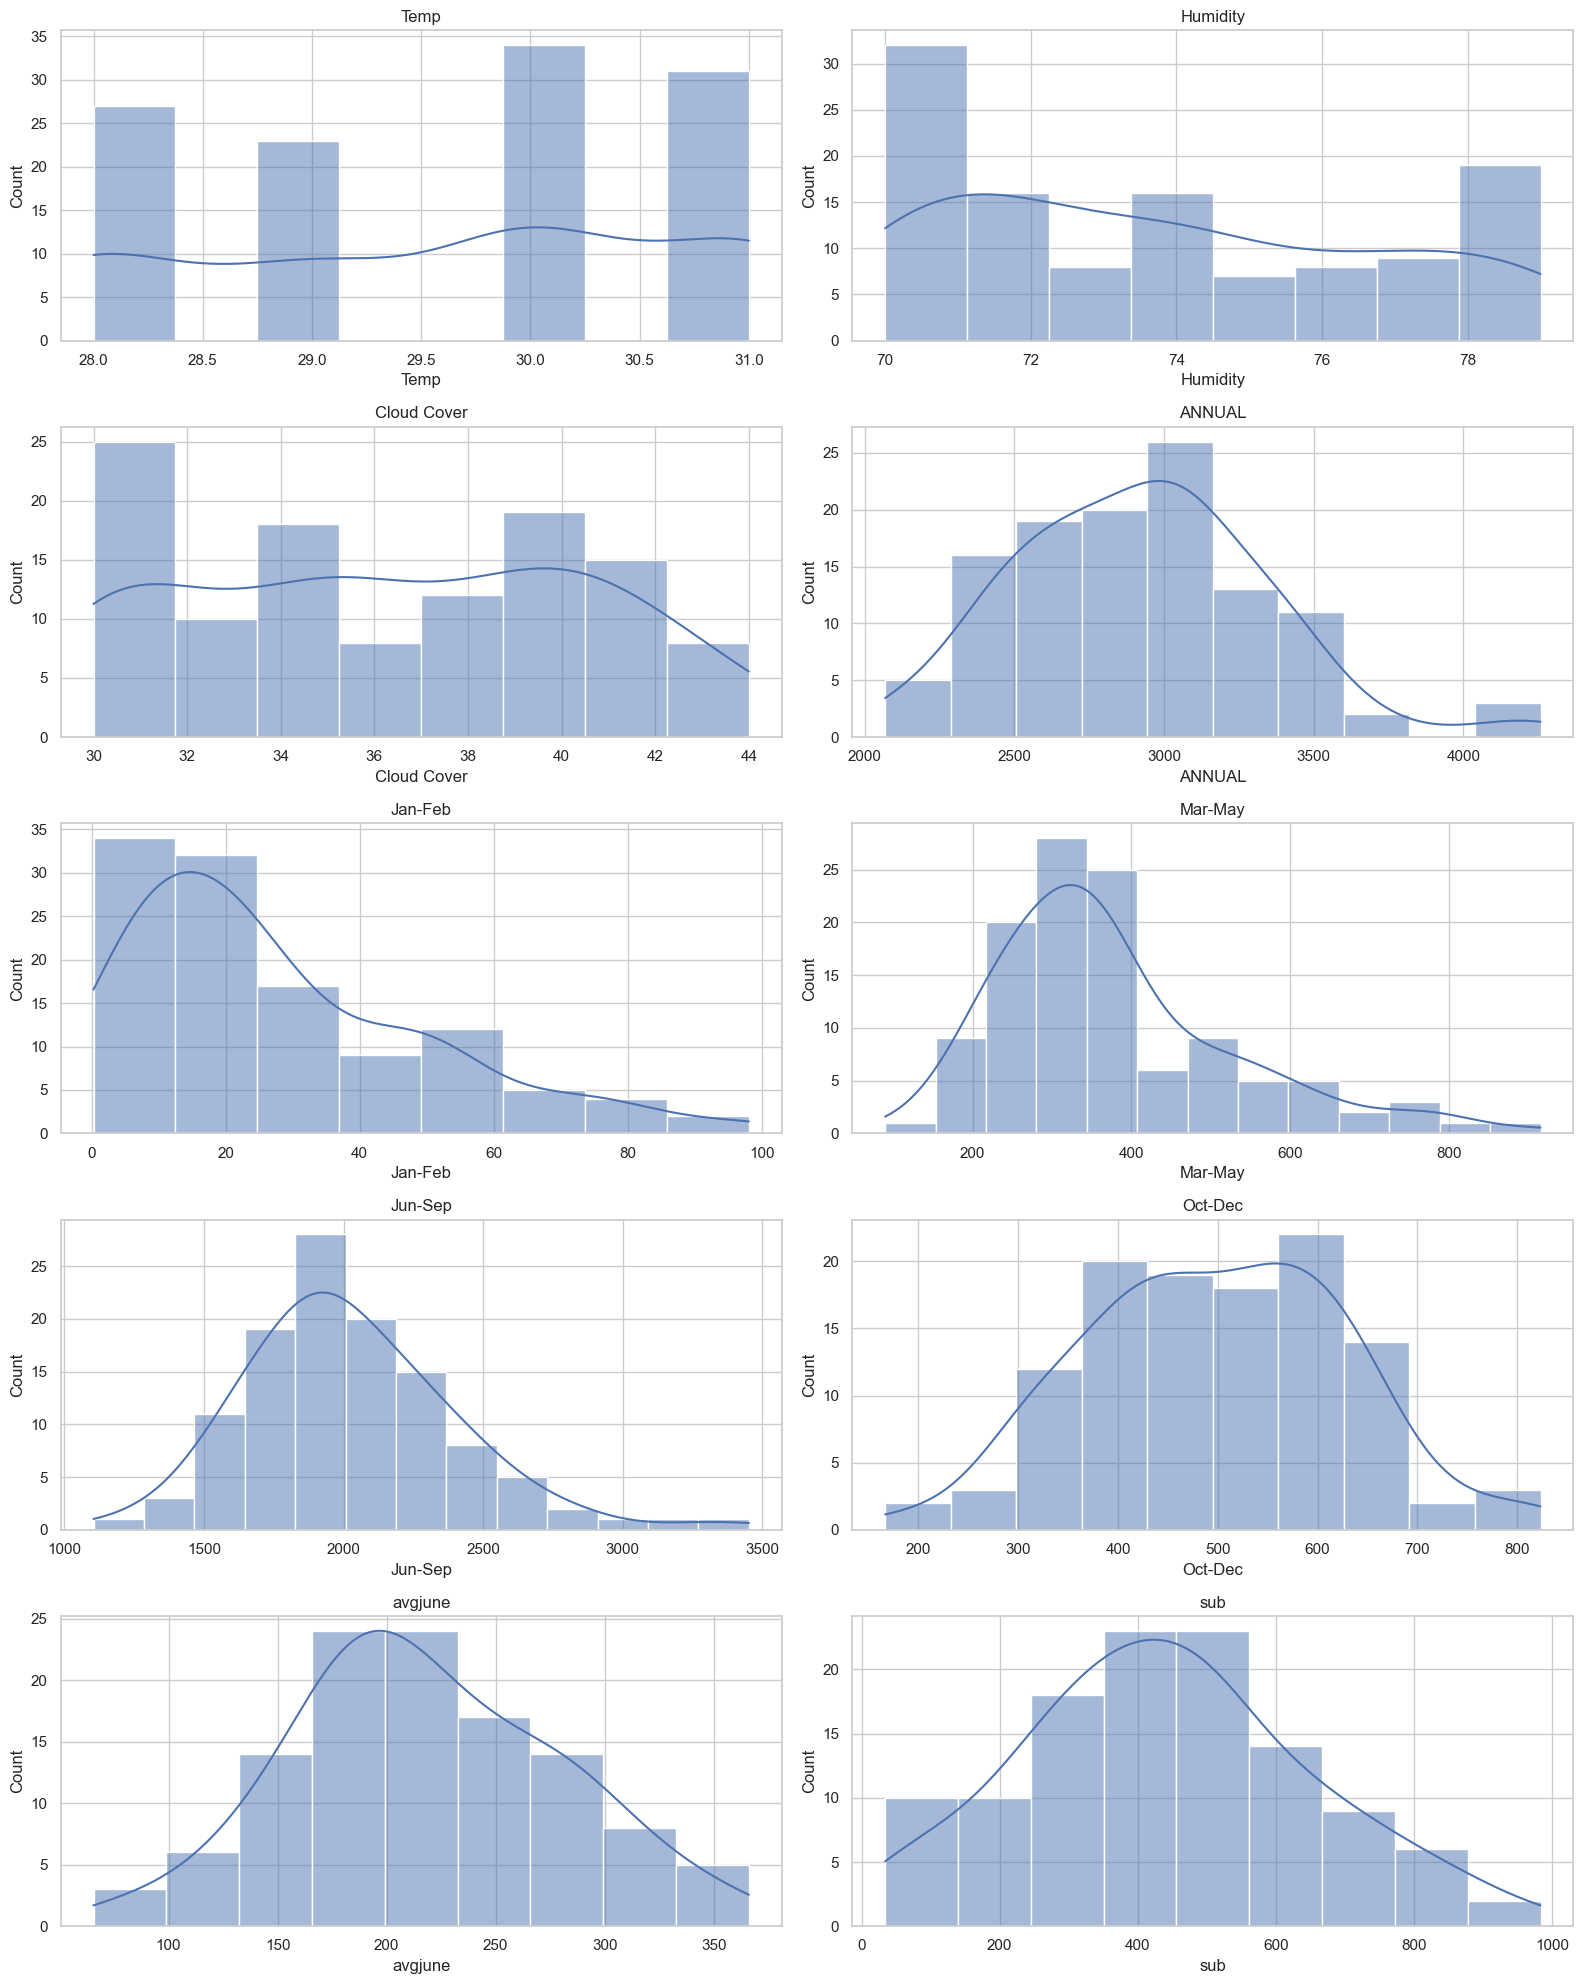

In [ ]:
fig, axes = plt.subplots(5, 2, figsize=(16,20))

axes = axes.flatten()

for i, column in enumerate(feature_columns):

    sns.histplot(
        df[column],
        kde=True,
        ax=axes[i]
    )

    axes[i].set_title(column)

plt.tight_layout()

plt.show()

### Observation

Distribution plots provide a clearer understanding of the density and spread of each numerical feature.

They help identify skewness, concentration of values, and possible deviations from a normal distribution.

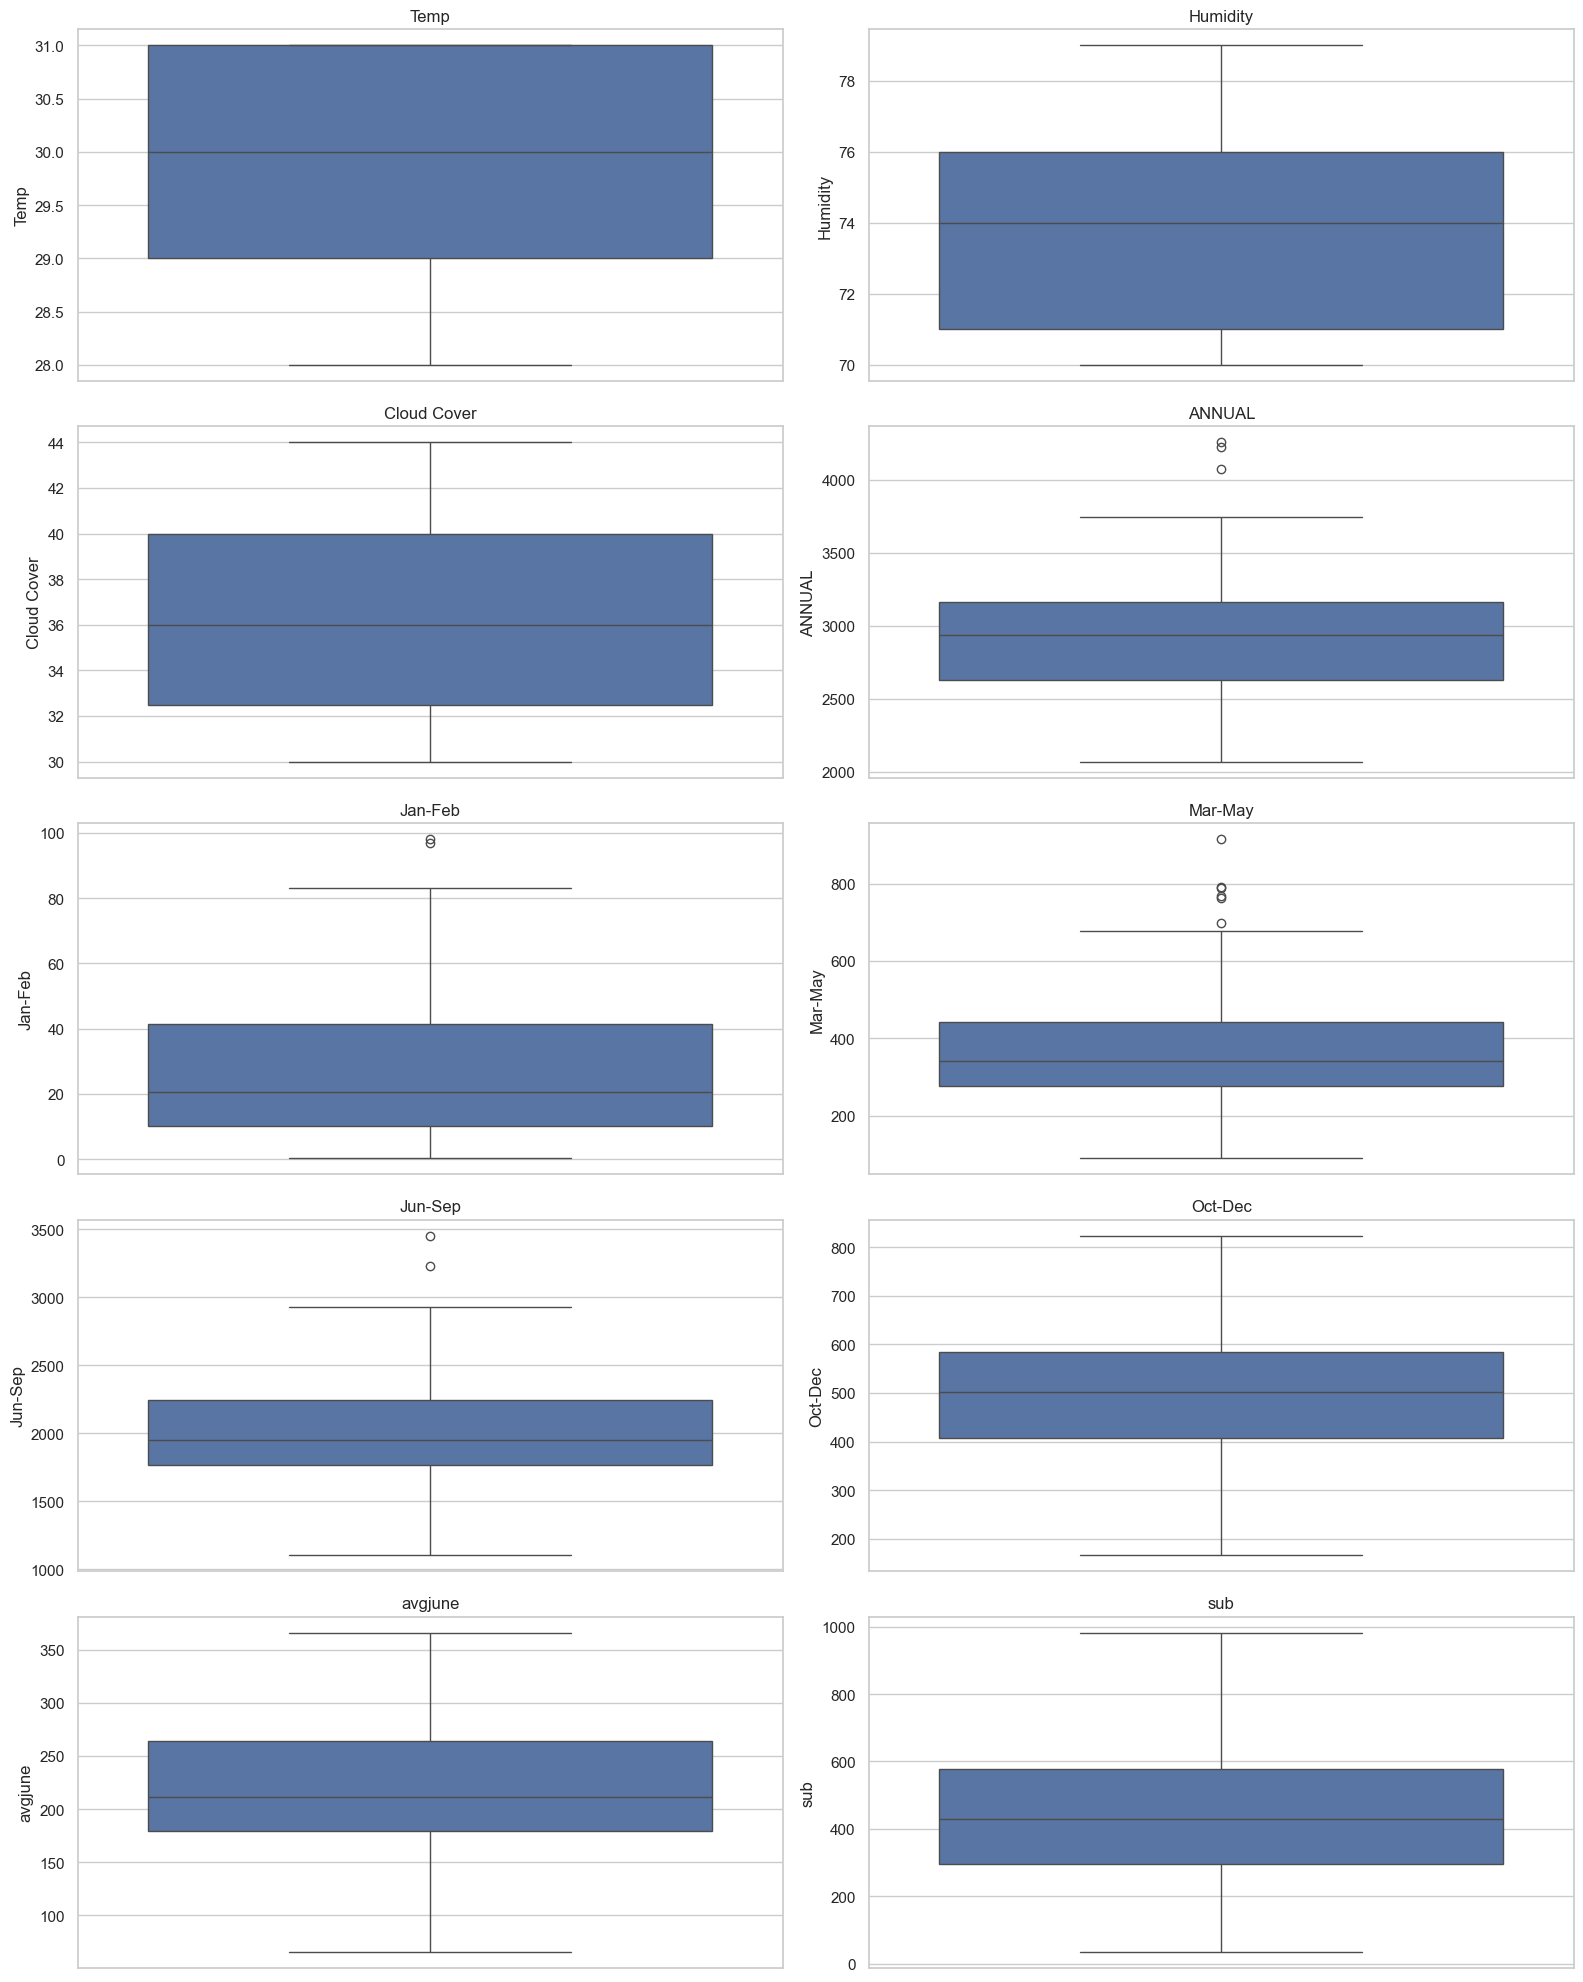

In [ ]:
fig, axes = plt.subplots(5,2, figsize=(16,20))

axes = axes.flatten()

for i, column in enumerate(feature_columns):

    sns.boxplot(
        y=df[column],
        ax=axes[i]
    )

    axes[i].set_title(column)

plt.tight_layout()

plt.show()

### Observation

Box plots reveal the spread of each feature and highlight potential outliers.

These observations will be useful during the preprocessing stage, where the IQR method will be applied for outlier treatment.

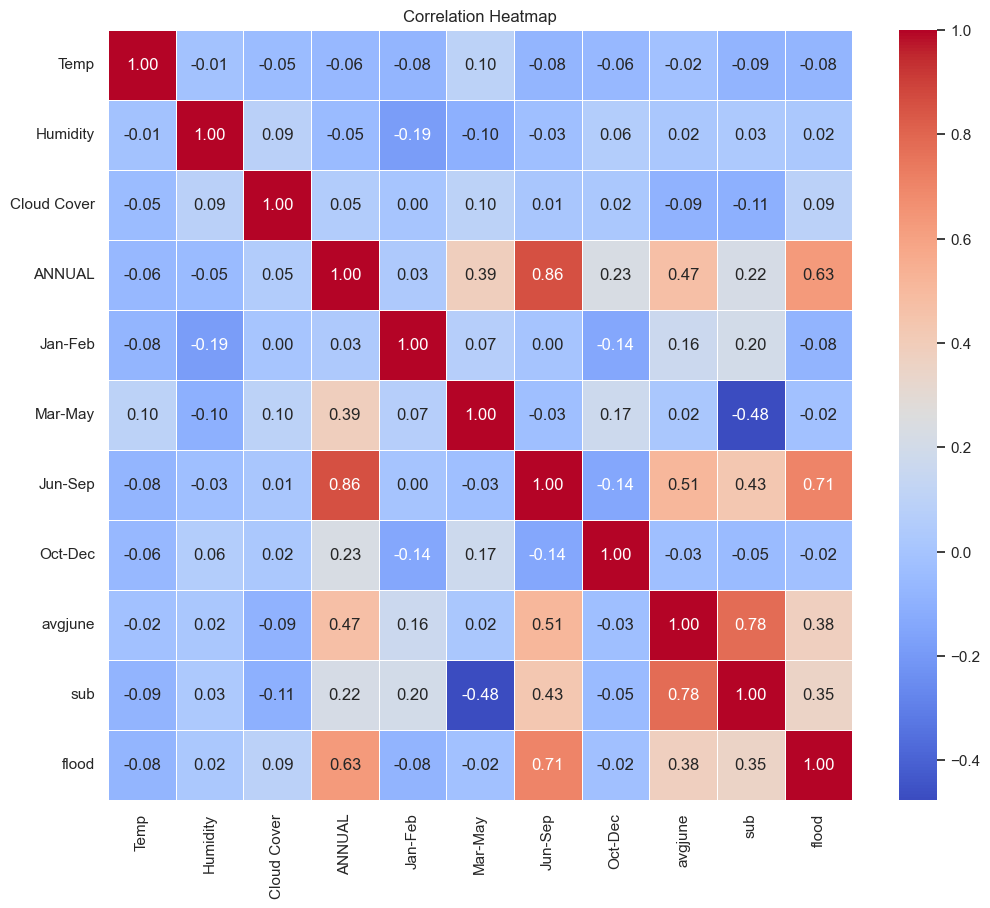

In [ ]:
plt.figure(figsize=(12,10))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm",
    linewidths=0.5,
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

### Observation

The heatmap displays the correlation between all numerical features.

Highly correlated features indicate strong relationships, while weak correlations suggest minimal influence. This analysis supports feature selection before model training.

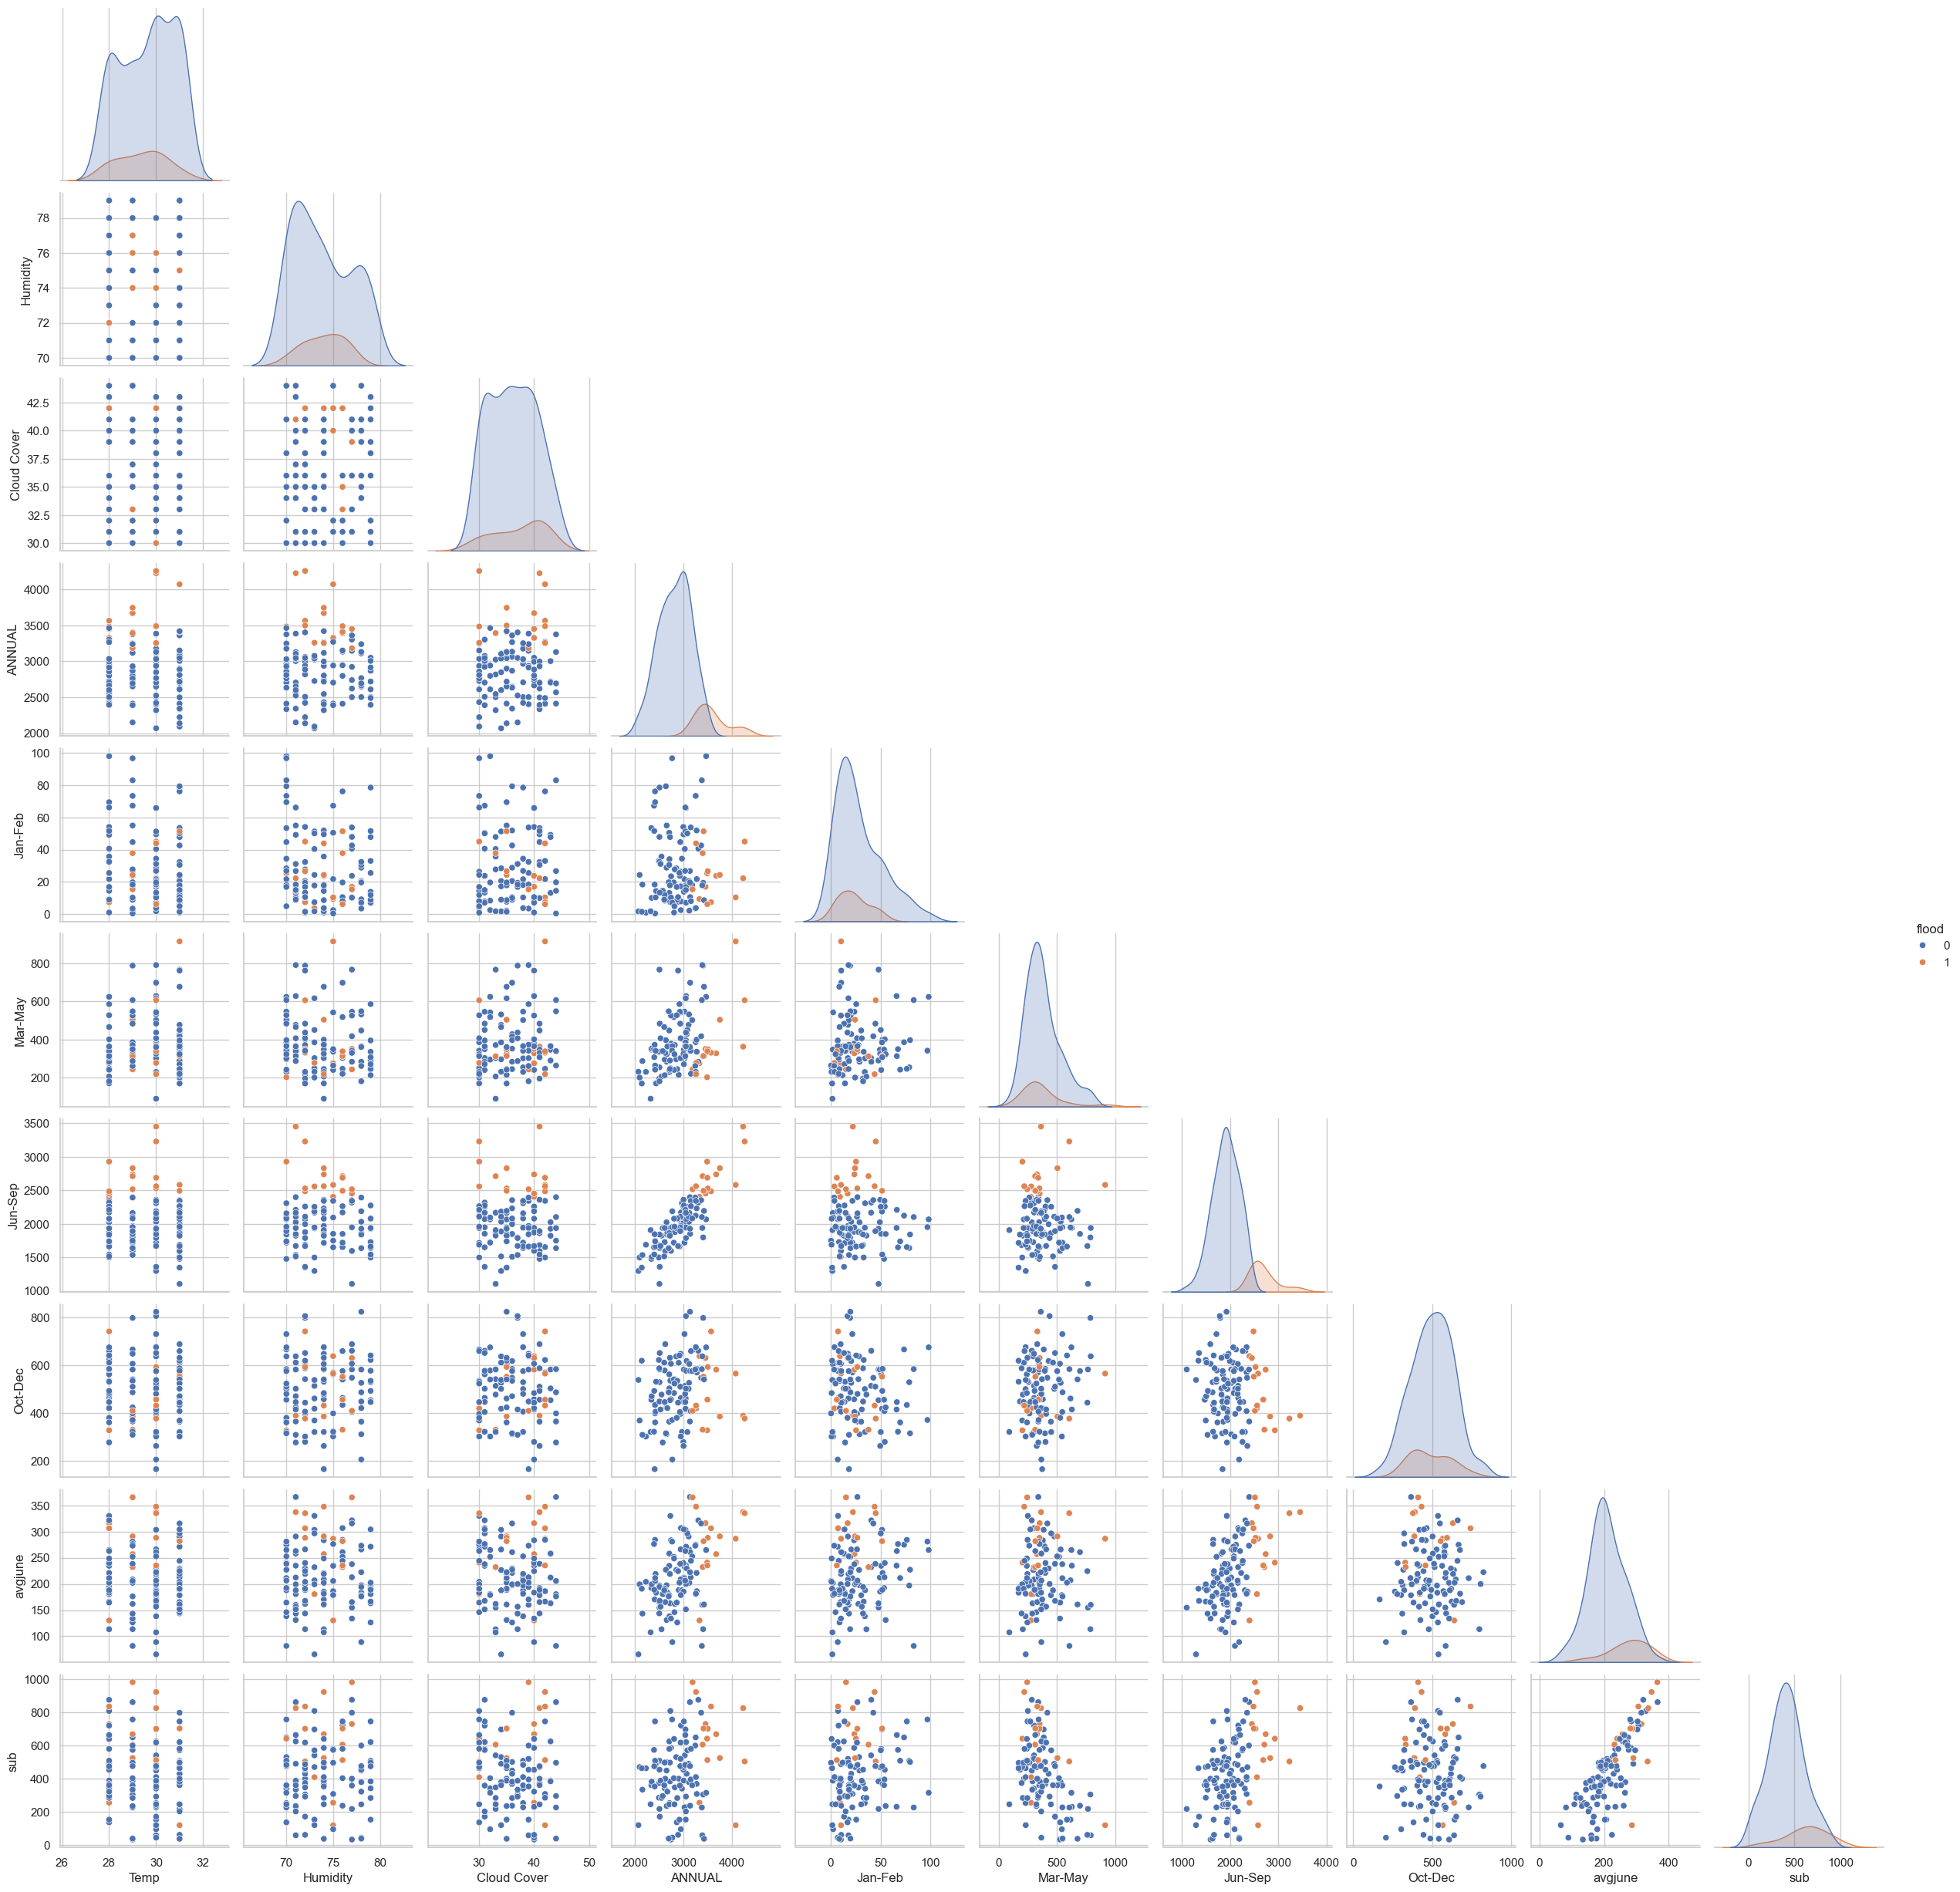

In [ ]:
sns.pairplot(
    df,
    hue="flood",
    corner=True
)

plt.show()

### Observation

The pair plot visualizes the relationship between multiple variables simultaneously.

It also illustrates how flood and non-flood records are distributed across different feature combinations.

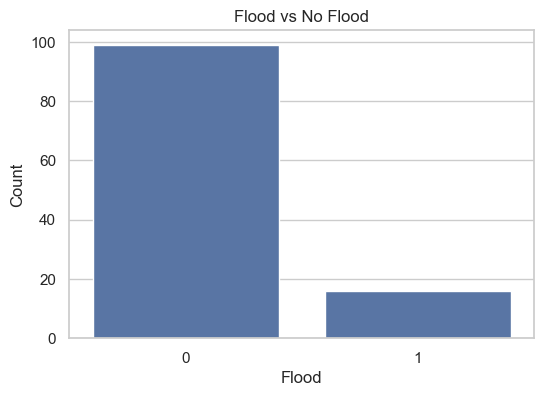

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="flood",
    data=df
)

plt.title("Flood vs No Flood")

plt.xlabel("Flood")

plt.ylabel("Count")

plt.show()

### Observation

The target distribution indicates whether the dataset is balanced or imbalanced.

A balanced dataset generally results in better model learning and improved prediction performance.

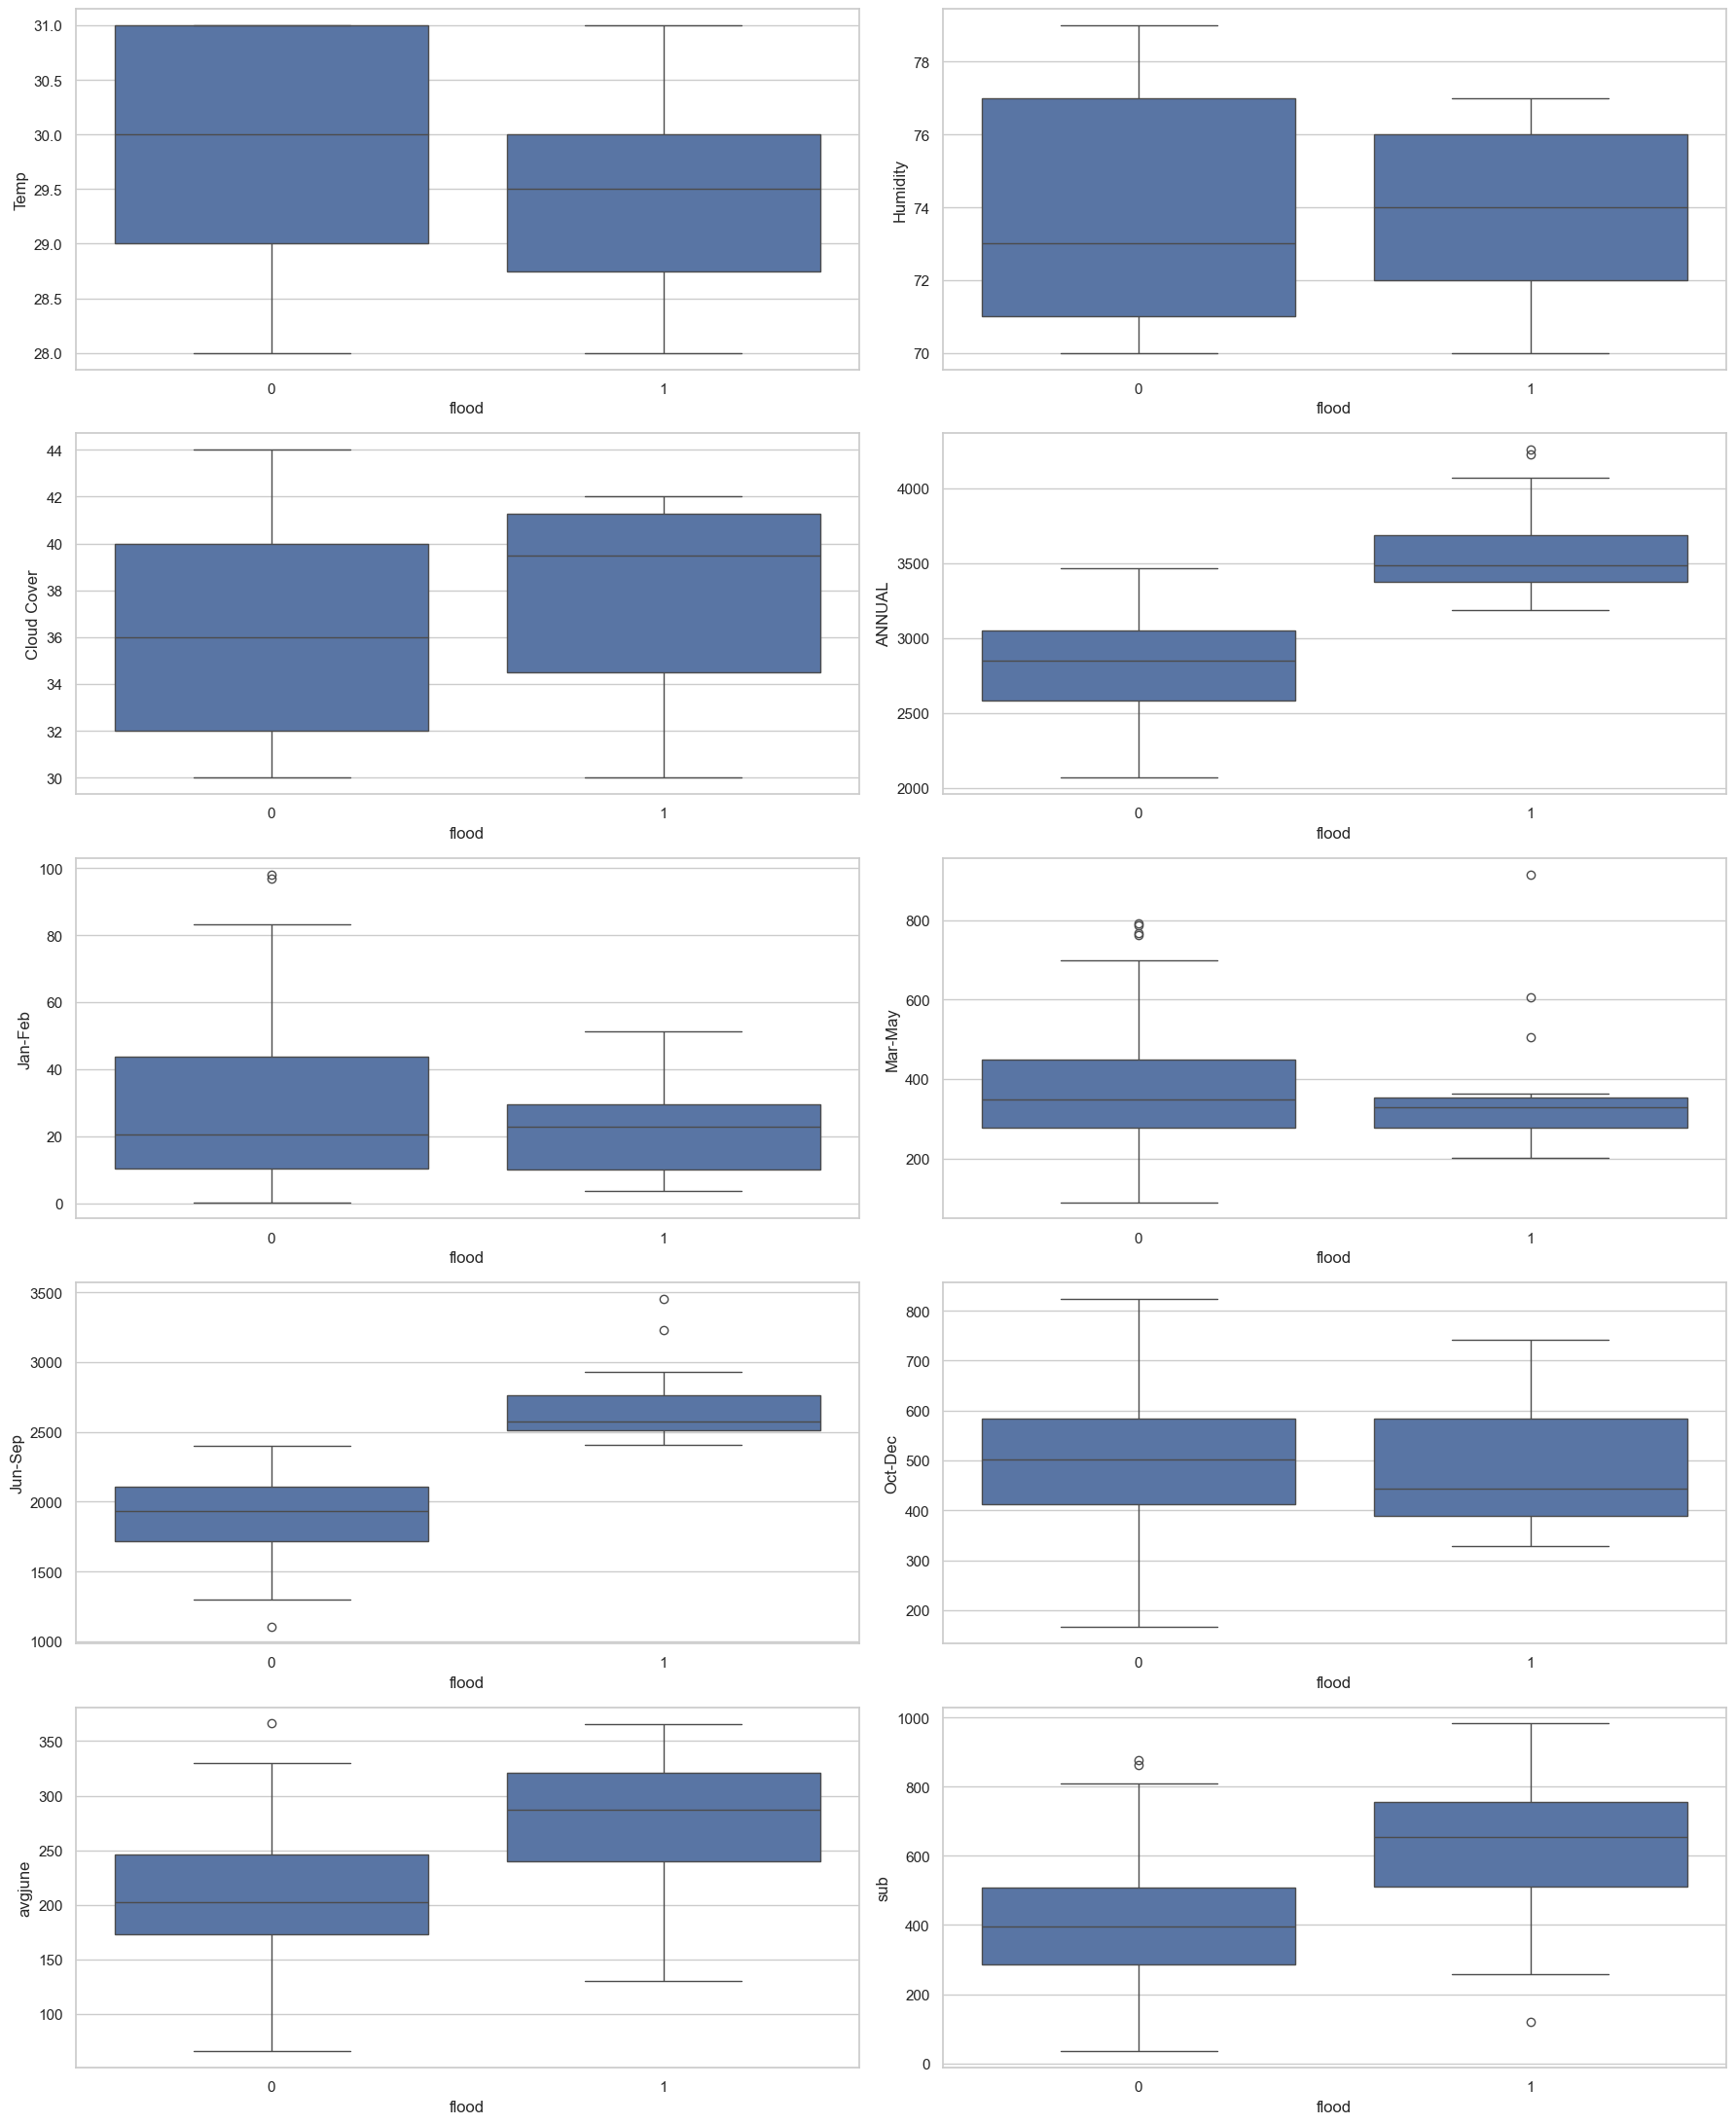

In [ ]:
fig, axes = plt.subplots(5,2, figsize=(18,22))

axes = axes.flatten()

for i, column in enumerate(feature_columns):

    sns.boxplot(
        x="flood",
        y=column,
        data=df,
        ax=axes[i]
    )

plt.tight_layout()

plt.show()

### Observation

These boxplots compare the distribution of each feature with respect to the target class.

Features showing noticeable differences between flood and non-flood classes are expected to contribute more significantly during model training.

In [ ]:
correlation = df.corr()["flood"].sort_values(ascending=False)

correlation

flood          1.000000
Jun-Sep        0.705202
ANNUAL         0.626874
avgjune        0.379778
sub            0.349828
Cloud Cover    0.089801
Humidity       0.020250
Mar-May       -0.017598
Oct-Dec       -0.024852
Temp          -0.080946
Jan-Feb       -0.084446
Name: flood, dtype: float64

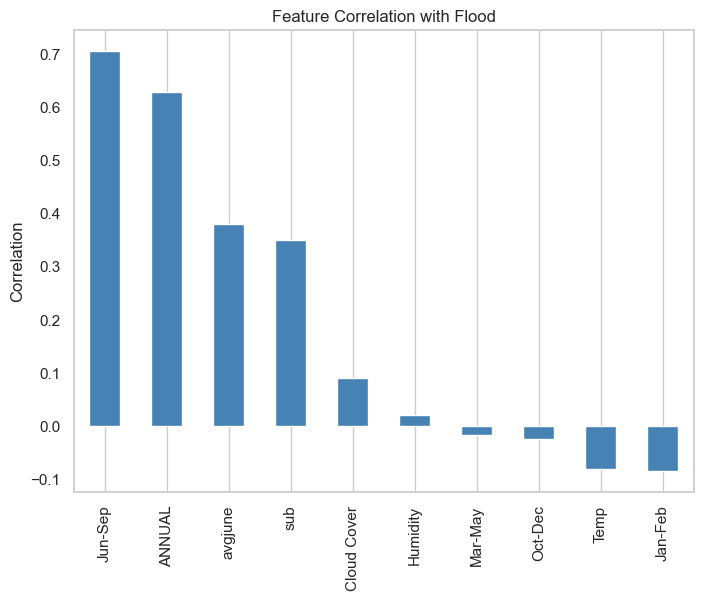

In [ ]:
plt.figure(figsize=(8,6))

correlation.drop("flood").plot(
    kind="bar",
    color="steelblue"
)

plt.title("Feature Correlation with Flood")

plt.ylabel("Correlation")

plt.grid(axis="y")

plt.show()

In [23]:
print("="*60)

print("Exploratory Data Analysis Summary")

print("="*60)

print(f"Total Records        : {df.shape[0]}")
print(f"Total Features       : {len(feature_columns)}")
print(f"Target Column        : {TARGET}")
print(f"Missing Values       : {df.isnull().sum().sum()}")
print(f"Duplicate Records    : {df.duplicated().sum()}")

print("\nMost Correlated Features with Flood\n")

print(correlation)

print("="*60)

Exploratory Data Analysis Summary
Total Records        : 115
Total Features       : 10
Target Column        : flood
Missing Values       : 0
Duplicate Records    : 0

Most Correlated Features with Flood

flood          1.000000
Jun-Sep        0.705202
ANNUAL         0.626874
avgjune        0.379778
sub            0.349828
Cloud Cover    0.089801
Humidity       0.020250
Mar-May       -0.017598
Oct-Dec       -0.024852
Temp          -0.080946
Jan-Feb       -0.084446
Name: flood, dtype: float64


# 3. Data Preprocessing

Data preprocessing is an important step in machine learning. It improves data quality, removes inconsistencies, and prepares the dataset for model training. In this project, preprocessing includes checking for missing values, detecting and treating outliers, separating features and target variables, splitting the dataset, and applying feature scaling.

In [ ]:
missing_values = df.isnull().sum()

print("Missing Values in Each Column")
print("-" * 50)

print(missing_values)

print("\nTotal Missing Values :", missing_values.sum())

Missing Values in Each Column
--------------------------------------------------
Temp           0
Humidity       0
Cloud Cover    0
ANNUAL         0
Jan-Feb        0
Mar-May        0
Jun-Sep        0
Oct-Dec        0
avgjune        0
sub            0
flood          0
dtype: int64

Total Missing Values : 0


In [ ]:
if missing_values.sum() == 0:
    print("Dataset contains no missing values.")
else:

    numeric_columns = df.select_dtypes(include=np.number).columns

    for column in numeric_columns:
        df[column].fillna(df[column].median(), inplace=True)

    print("Missing values handled successfully.")

Dataset contains no missing values.


In [ ]:
outlier_summary = {}

for column in feature_columns:

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = ((df[column] < lower) | (df[column] > upper)).sum()

    outlier_summary[column] = outliers

outlier_df = pd.DataFrame(
    outlier_summary.items(),
    columns=["Feature", "Outliers"]
)

outlier_df

,Feature,Outliers
0,Temp,0
1,Humidity,0
2,Cloud Cover,0
3,ANNUAL,3
4,Jan-Feb,2
5,Mar-May,6
6,Jun-Sep,2
7,Oct-Dec,0
8,avgjune,0
9,sub,0


In [ ]:
for column in feature_columns:

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[column] = np.where(
        df[column] < lower,
        lower,
        df[column]
    )

    df[column] = np.where(
        df[column] > upper,
        upper,
        df[column]
    )

print("Outliers treated successfully using IQR Capping.")

Outliers treated successfully using IQR Capping.


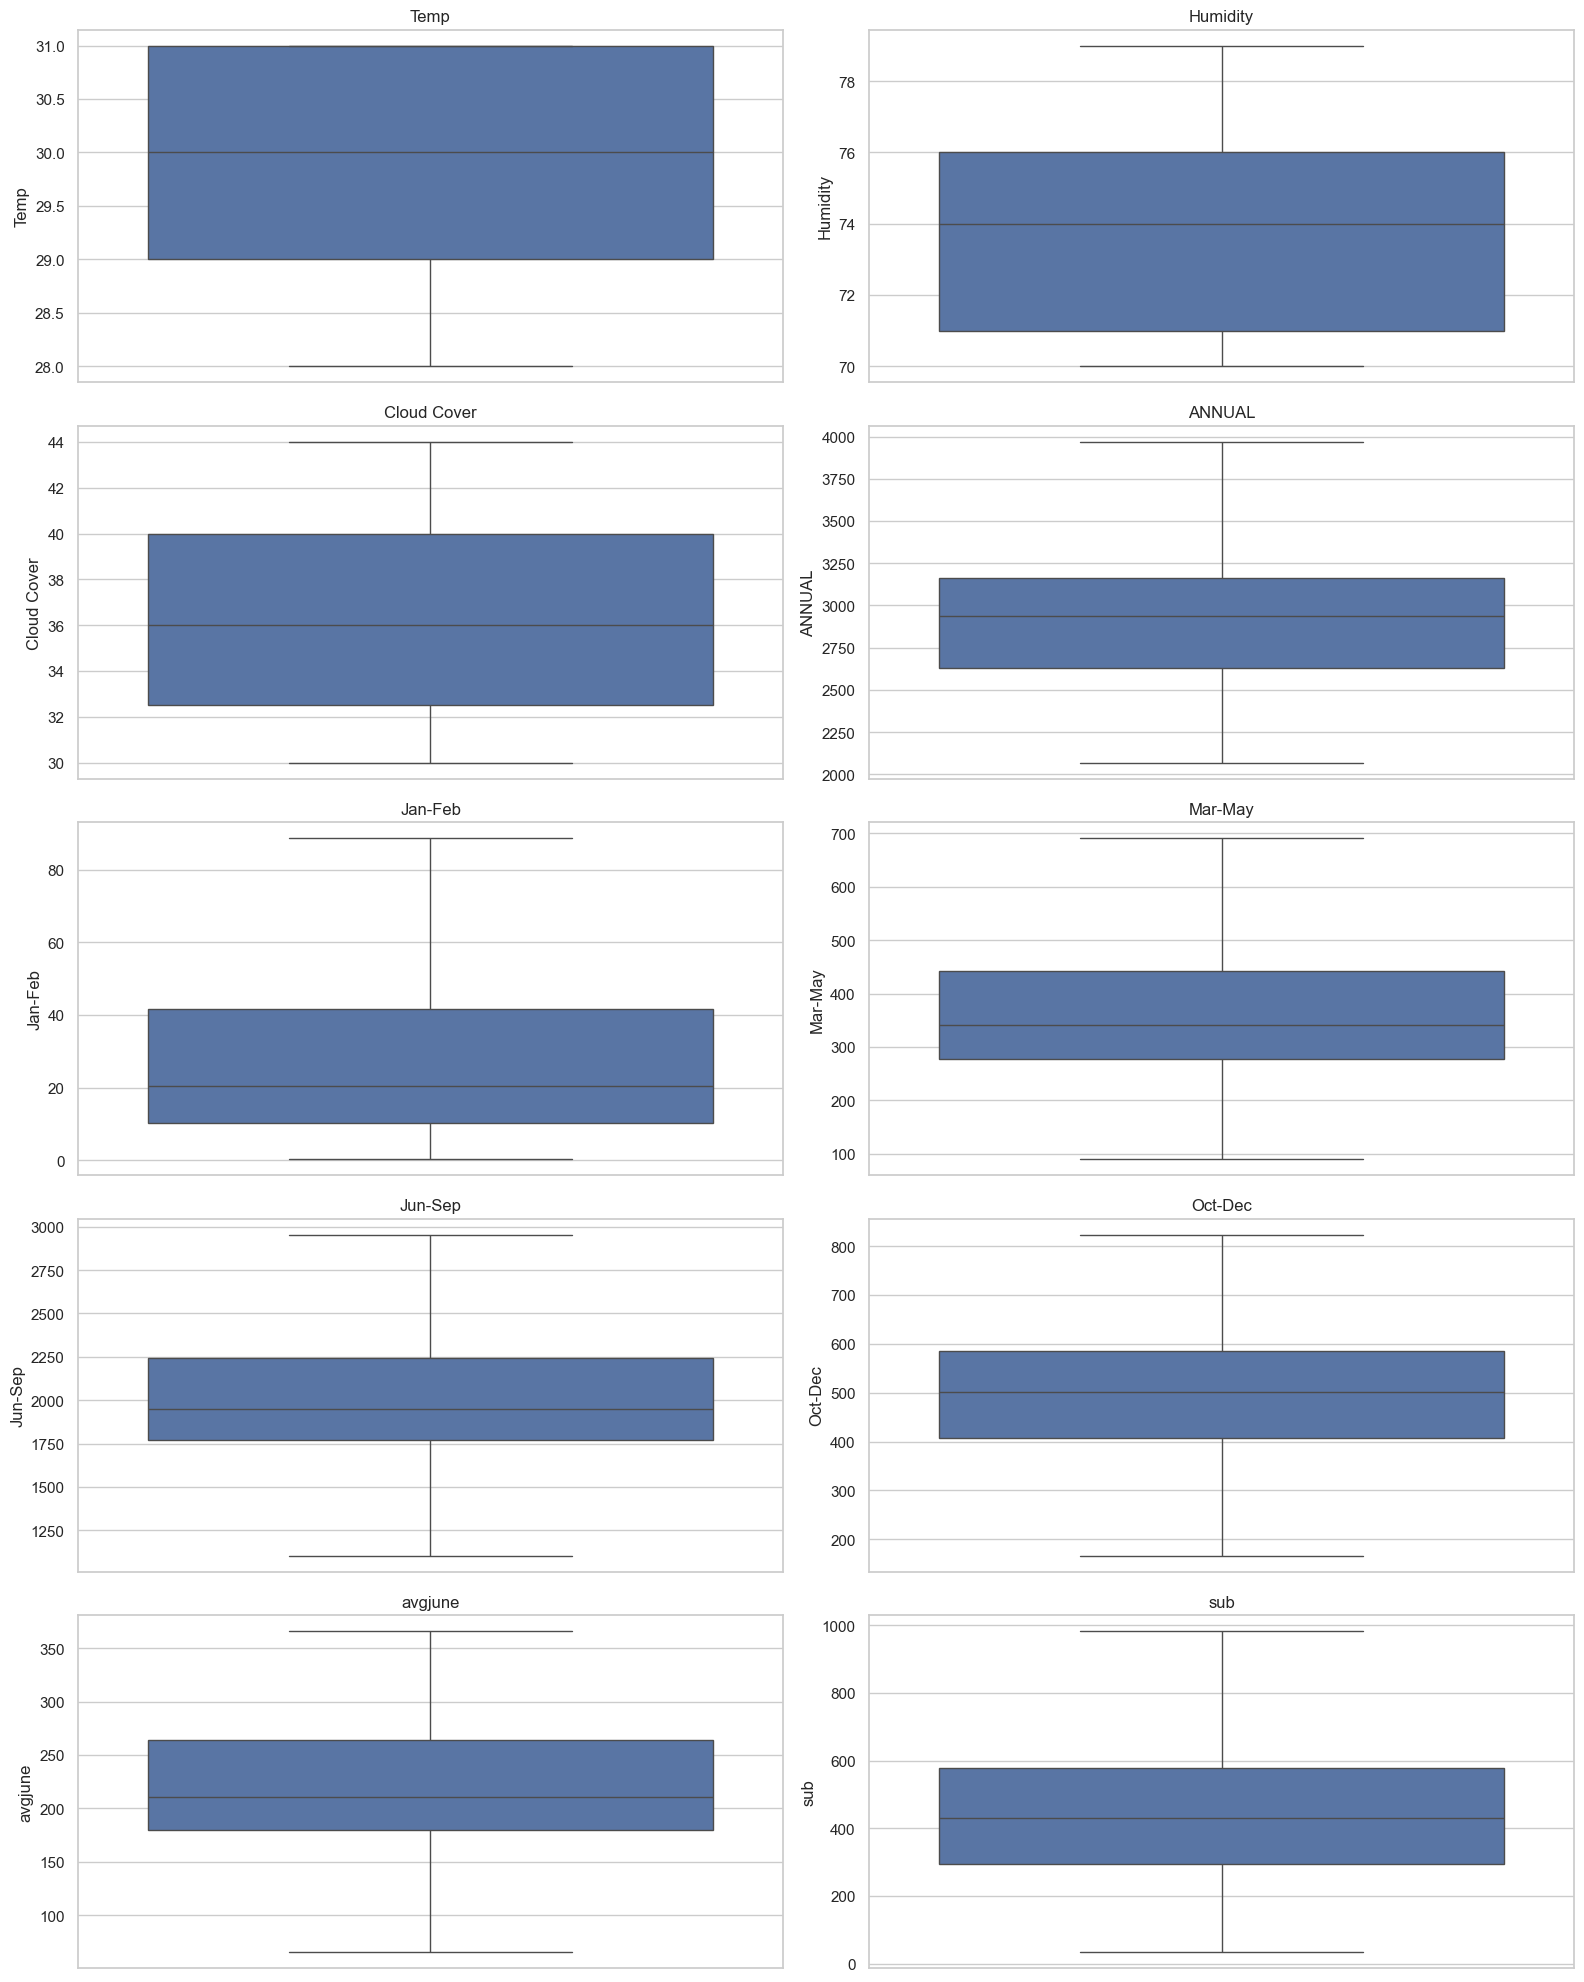

In [ ]:
fig, axes = plt.subplots(5, 2, figsize=(16, 20))

axes = axes.flatten()

for i, column in enumerate(feature_columns):

    sns.boxplot(y=df[column], ax=axes[i])

    axes[i].set_title(column)

plt.tight_layout()

plt.show()

In [ ]:
categorical_columns = df.select_dtypes(exclude=np.number).columns

if len(categorical_columns) == 0:

    print("No categorical columns found.")
    print("Feature encoding is not required.")

else:

    encoder = LabelEncoder()

    for column in categorical_columns:

        df[column] = encoder.fit_transform(df[column])

    print("Categorical features encoded successfully.")

No categorical columns found.
Feature encoding is not required.


In [ ]:
X = df.drop(columns=TARGET)

y = df[TARGET]

print("Feature Matrix Shape :", X.shape)

print("Target Shape :", y.shape)

Feature Matrix Shape : (115, 10)
Target Shape : (115,)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.20,

    random_state=42,

    stratify=y

)

print("Training Samples :", X_train.shape)

print("Testing Samples :", X_test.shape)

Training Samples : (92, 10)
Testing Samples : (23, 10)


In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

print("Feature Scaling Completed.")

Feature Scaling Completed.


In [ ]:
scaler_path = MODEL_DIR / "scaler.pkl"

joblib.dump(scaler, scaler_path)

print("Scaler saved successfully.")

print(scaler_path)

Scaler saved successfully.
c:\projects\Raising Water(APSCHE)\backend\models\scaler.pkl


In [34]:
print("=" * 60)

print("Preprocessing Summary")

print("=" * 60)

print("Missing Values      :", df.isnull().sum().sum())

print("Duplicate Records   :", df.duplicated().sum())

print("Feature Scaling     : Completed")

print("Train Samples       :", X_train.shape[0])

print("Test Samples        :", X_test.shape[0])

print("Scaler Saved        :", scaler_path)

print("=" * 60)

Preprocessing Summary
Missing Values      : 0
Duplicate Records   : 0
Feature Scaling     : Completed
Train Samples       : 92
Test Samples        : 23
Scaler Saved        : c:\projects\Raising Water(APSCHE)\backend\models\scaler.pkl


# 4. Model Building

In this section, multiple machine learning classification algorithms are trained and evaluated to identify the best-performing model for flood prediction.

The following models are implemented:

- Decision Tree
- Random Forest
- K-Nearest Neighbors (KNN)
- XGBoost

Each model is evaluated using:

- Accuracy Score
- Confusion Matrix
- Classification Report

In [ ]:
model_results = {}
trained_models = {}

In [ ]:
dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)

dt_prediction = dt_model.predict(X_test)

dt_accuracy = accuracy_score(y_test, dt_prediction)

print("="*60)
print("Decision Tree")
print("="*60)

print(f"Accuracy : {dt_accuracy:.4f}")

print("\nConfusion Matrix\n")
print(confusion_matrix(y_test, dt_prediction))

print("\nClassification Report\n")
print(classification_report(y_test, dt_prediction))

model_results["Decision Tree"] = dt_accuracy
trained_models["Decision Tree"] = dt_model

Decision Tree
Accuracy : 0.9565

Confusion Matrix

[[20  0]
 [ 1  2]]

Classification Report

              precision    recall  f1-score   support

           0       0.95      1.00      0.98        20
           1       1.00      0.67      0.80         3

    accuracy                           0.96        23
   macro avg       0.98      0.83      0.89        23
weighted avg       0.96      0.96      0.95        23



In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_prediction = rf_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_prediction)

print("="*60)
print("Random Forest")
print("="*60)

print(f"Accuracy : {rf_accuracy:.4f}")

print("\nConfusion Matrix\n")
print(confusion_matrix(y_test, rf_prediction))

print("\nClassification Report\n")
print(classification_report(y_test, rf_prediction))

model_results["Random Forest"] = rf_accuracy
trained_models["Random Forest"] = rf_model

Random Forest
Accuracy : 0.9565

Confusion Matrix

[[20  0]
 [ 1  2]]

Classification Report

              precision    recall  f1-score   support

           0       0.95      1.00      0.98        20
           1       1.00      0.67      0.80         3

    accuracy                           0.96        23
   macro avg       0.98      0.83      0.89        23
weighted avg       0.96      0.96      0.95        23



In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_prediction = rf_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_prediction)

print("="*60)
print("Random Forest")
print("="*60)

print(f"Accuracy : {rf_accuracy:.4f}")

print("\nConfusion Matrix\n")
print(confusion_matrix(y_test, rf_prediction))

print("\nClassification Report\n")
print(classification_report(y_test, rf_prediction))

model_results["Random Forest"] = rf_accuracy
trained_models["Random Forest"] = rf_model

Random Forest
Accuracy : 0.9565

Confusion Matrix

[[20  0]
 [ 1  2]]

Classification Report

              precision    recall  f1-score   support

           0       0.95      1.00      0.98        20
           1       1.00      0.67      0.80         3

    accuracy                           0.96        23
   macro avg       0.98      0.83      0.89        23
weighted avg       0.96      0.96      0.95        23



In [ ]:
knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_train, y_train)

knn_prediction = knn_model.predict(X_test)

knn_accuracy = accuracy_score(y_test, knn_prediction)

print("="*60)
print("K-Nearest Neighbors")
print("="*60)

print(f"Accuracy : {knn_accuracy:.4f}")

print("\nConfusion Matrix\n")
print(confusion_matrix(y_test, knn_prediction))

print("\nClassification Report\n")
print(classification_report(y_test, knn_prediction))

model_results["KNN"] = knn_accuracy
trained_models["KNN"] = knn_model

K-Nearest Neighbors
Accuracy : 0.8696

Confusion Matrix

[[19  1]
 [ 2  1]]

Classification Report

              precision    recall  f1-score   support

           0       0.90      0.95      0.93        20
           1       0.50      0.33      0.40         3

    accuracy                           0.87        23
   macro avg       0.70      0.64      0.66        23
weighted avg       0.85      0.87      0.86        23



In [ ]:
xgb_model = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(X_train, y_train)

xgb_prediction = xgb_model.predict(X_test)

xgb_accuracy = accuracy_score(y_test, xgb_prediction)

print("="*60)
print("XGBoost")
print("="*60)

print(f"Accuracy : {xgb_accuracy:.4f}")

print("\nConfusion Matrix\n")
print(confusion_matrix(y_test, xgb_prediction))

print("\nClassification Report\n")
print(classification_report(y_test, xgb_prediction))

model_results["XGBoost"] = xgb_accuracy
trained_models["XGBoost"] = xgb_model

XGBoost
Accuracy : 0.8696

Confusion Matrix

[[20  0]
 [ 3  0]]

Classification Report

              precision    recall  f1-score   support

           0       0.87      1.00      0.93        20
           1       0.00      0.00      0.00         3

    accuracy                           0.87        23
   macro avg       0.43      0.50      0.47        23
weighted avg       0.76      0.87      0.81        23



In [ ]:
comparison = pd.DataFrame(
    model_results.items(),
    columns=["Model", "Accuracy"]
)

comparison = comparison.sort_values(
    by="Accuracy",
    ascending=False
)

comparison.reset_index(drop=True, inplace=True)

comparison

,Model,Accuracy
0,Decision Tree,0.956522
1,Random Forest,0.956522
2,KNN,0.869565
3,XGBoost,0.869565


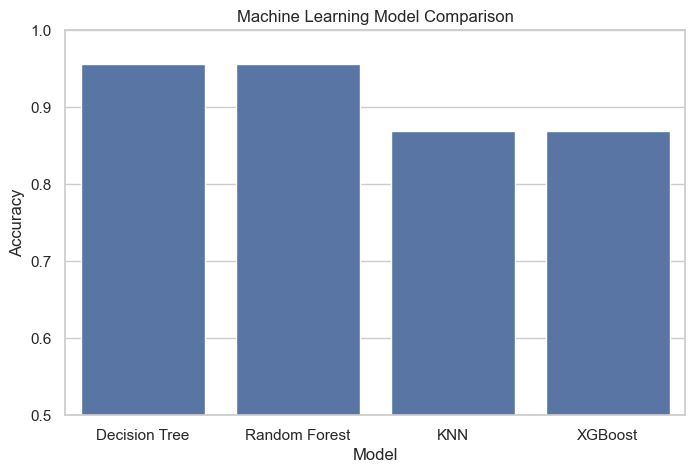

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=comparison,
    x="Model",
    y="Accuracy"
)

plt.title("Machine Learning Model Comparison")

plt.ylim(0.5,1)

plt.show()

In [ ]:
best_model_name = comparison.iloc[0]["Model"]

best_model = trained_models[best_model_name]

print("="*60)

print("Best Model Selected")

print("="*60)

print(best_model_name)

print("="*60)

Best Model Selected
Decision Tree


In [ ]:
model_path = MODEL_DIR / "flood_model.pkl"

joblib.dump(best_model, model_path)

print("Model Saved Successfully")

print(model_path)

Model Saved Successfully
c:\projects\Raising Water(APSCHE)\backend\models\flood_model.pkl


In [ ]:
loaded_model = joblib.load(model_path)

print(type(loaded_model))

print("Model Loaded Successfully")

<class 'sklearn.tree._classes.DecisionTreeClassifier'>
Model Loaded Successfully


In [46]:
print("="*60)

print("Model Training Summary")

print("="*60)

print(comparison)

print()

print("Best Model :", best_model_name)

print("Model Saved :", model_path)

print("Scaler Saved :", scaler_path)

print("="*60)

Model Training Summary
           Model  Accuracy
0  Decision Tree  0.956522
1  Random Forest  0.956522
2            KNN  0.869565
3        XGBoost  0.869565

Best Model : Decision Tree
Model Saved : c:\projects\Raising Water(APSCHE)\backend\models\flood_model.pkl
Scaler Saved : c:\projects\Raising Water(APSCHE)\backend\models\scaler.pkl
